<a href="https://colab.research.google.com/github/ntlcs/fiap-pos-ia-tech-challenge-fase-1-extra-visao-computacional/blob/main/01_Visao_Computacional_Pneumonia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🫁 Tech Challenge – Fase 1 | Projeto Extra

## Detecção de Pneumonia em Radiografias Torácicas utilizando Deep Learning, Redes Neurais Convolucionais (CNN) e Visão Computacional.

**Pós-Graduação em Inteligência Artificial – FIAP**

**Autora:** Natalia da Costa Silva

---

## Objetivo

Desenvolver uma solução de Visão Computacional capaz de classificar radiografias torácicas em duas categorias:

- `NORMAL`: radiografia sem indicativo de pneumonia;
- `PNEUMONIA`: radiografia com indicativo de pneumonia.

Este projeto corresponde à atividade complementar de Visão Computacional do Tech Challenge – Fase 1.

In [1]:
from pathlib import Path
import hashlib
import random
import re

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from PIL import Image, UnidentifiedImageError

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

# 1. Carregamento do Dataset

O dataset utilizado contém radiografias torácicas organizadas em classes que representam exames normais e exames com pneumonia.

Nesta etapa, o conjunto de dados é baixado e sua estrutura de diretórios é inspecionada antes de qualquer transformação.

In [3]:
dataset_path = Path(
    kagglehub.dataset_download(
        "paultimothymooney/chest-xray-pneumonia"
    )
)

print(f"Dataset baixado em: {dataset_path}")

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Dataset baixado em: /kaggle/input/chest-xray-pneumonia


In [4]:
candidatas = [
    pasta
    for pasta in dataset_path.rglob("chest_xray")
    if pasta.is_dir()
]

data_dir = next(
    (
        pasta
        for pasta in candidatas
        if all((pasta / split).is_dir() for split in ["train", "val", "test"])
    ),
    None
)

if data_dir is None:
    raise FileNotFoundError(
        "Não foi encontrada uma pasta 'chest_xray' contendo train, val e test."
    )

print(f"Pasta principal encontrada: {data_dir}")

Pasta principal encontrada: /kaggle/input/chest-xray-pneumonia/chest_xray


In [5]:
for split in ["train", "val", "test"]:
    print(f"📁 {split}")

    for classe in ["NORMAL", "PNEUMONIA"]:
        pasta_classe = data_dir / split / classe
        status = "encontrada" if pasta_classe.is_dir() else "ausente"
        print(f"    📁 {classe}: {status}")

📁 train
    📁 NORMAL: encontrada
    📁 PNEUMONIA: encontrada
📁 val
    📁 NORMAL: encontrada
    📁 PNEUMONIA: encontrada
📁 test
    📁 NORMAL: encontrada
    📁 PNEUMONIA: encontrada


# 2. Construção do Catálogo das Imagens

Para analisar o conjunto de dados de forma estruturada, será criado um DataFrame contendo:

- caminho da imagem;
- conjunto ao qual pertence;
- classe;
- extensão do arquivo;
- largura e altura;
- modo de cor;
- tamanho do arquivo.

In [6]:
extensoes_validas = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp"
}

registros = []
arquivos_corrompidos = []

for split in ["train", "val", "test"]:
    split_dir = data_dir / split

    for classe in ["NORMAL", "PNEUMONIA"]:
        classe_dir = split_dir / classe

        if not classe_dir.exists():
            print(f"Pasta não encontrada: {classe_dir}")
            continue

        for arquivo in sorted(classe_dir.iterdir()):
            if arquivo.suffix.lower() not in extensoes_validas:
                continue

            try:
                with Image.open(arquivo) as imagem:
                    largura, altura = imagem.size

                    registros.append({
                        "arquivo": arquivo.name,
                        "caminho": str(arquivo),
                        "split": split,
                        "classe": classe,
                        "extensao": arquivo.suffix.lower(),
                        "largura": largura,
                        "altura": altura,
                        "modo_cor": imagem.mode,
                        "tamanho_kb": arquivo.stat().st_size / 1024
                    })

            except (
                UnidentifiedImageError,
                OSError
            ) as erro:
                arquivos_corrompidos.append({
                    "arquivo": str(arquivo),
                    "erro": str(erro)
                })

df_imagens = pd.DataFrame(registros)

print(f"Total de imagens válidas: {len(df_imagens)}")
print(f"Total de arquivos corrompidos: {len(arquivos_corrompidos)}")

display(df_imagens.head())

Total de imagens válidas: 5856
Total de arquivos corrompidos: 0


,arquivo,caminho,split,classe,extensao,largura,altura,modo_cor,tamanho_kb
0,IM-0115-0001.jpeg,/kaggle/input/chest-xray-pneumonia/chest_xray/...,train,NORMAL,.jpeg,2090,1858,L,850.375000
1,IM-0117-0001.jpeg,/kaggle/input/chest-xray-pneumonia/chest_xray/...,train,NORMAL,.jpeg,1422,1152,L,396.782227
2,IM-0119-0001.jpeg,/kaggle/input/chest-xray-pneumonia/chest_xray/...,train,NORMAL,.jpeg,1810,1434,L,568.983398
3,IM-0122-0001.jpeg,/kaggle/input/chest-xray-pneumonia/chest_xray/...,train,NORMAL,.jpeg,1618,1279,L,460.503906
4,IM-0125-0001.jpeg,/kaggle/input/chest-xray-pneumonia/chest_xray/...,train,NORMAL,.jpeg,1600,1125,L,440.714844


In [7]:
df_imagens.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5856 entries, 0 to 5855
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   arquivo     5856 non-null   object 
 1   caminho     5856 non-null   object 
 2   split       5856 non-null   object 
 3   classe      5856 non-null   object 
 4   extensao    5856 non-null   object 
 5   largura     5856 non-null   int64  
 6   altura      5856 non-null   int64  
 7   modo_cor    5856 non-null   object 
 8   tamanho_kb  5856 non-null   float64
dtypes: float64(1), int64(2), object(6)
memory usage: 411.9+ KB


In [8]:
display(
    df_imagens.describe(
        include="all"
    ).transpose()
)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
arquivo,5856,5856,person83_bacteria_411.jpeg,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
caminho,5856,5856,/kaggle/input/chest-xray-pneumonia/chest_xray/...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
split,5856,3,train,5216,NaN,NaN,NaN,NaN,NaN,NaN,NaN
classe,5856,2,PNEUMONIA,4273,NaN,NaN,NaN,NaN,NaN,NaN,NaN
extensao,5856,1,.jpeg,5856,NaN,NaN,NaN,NaN,NaN,NaN,NaN
largura,5856.0,NaN,NaN,NaN,1327.880806,363.500922,384.0,1056.0,1281.0,1560.0,2916.0
altura,5856.0,NaN,NaN,NaN,970.689037,383.392117,127.0,688.0,888.0,1187.0,2713.0
modo_cor,5856,2,L,5573,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tamanho_kb,5856.0,NaN,NaN,NaN,206.199238,258.600371,5.313477,54.750977,93.592773,230.484619,2357.755859


In [9]:
df_imagens.isna().sum()

,0
arquivo,0
caminho,0
split,0
classe,0
extensao,0
largura,0
altura,0
modo_cor,0
tamanho_kb,0


In [10]:
df_imagens["extensao"].value_counts()

,count
extensao,
.jpeg,5856


In [11]:
df_imagens["modo_cor"].value_counts()

,count
modo_cor,
L,5573
RGB,283


# 3. Distribuição das Imagens

A distribuição das imagens será analisada por classe e por conjunto de dados, permitindo identificar:

- desbalanceamento entre `NORMAL` e `PNEUMONIA`;
- diferenças de tamanho entre treino, validação e teste;
- possíveis riscos para o processo de avaliação.

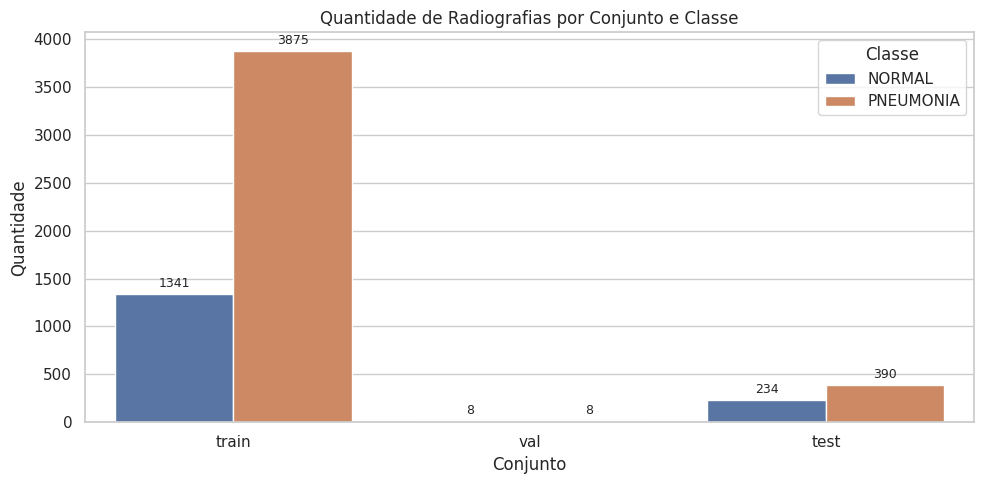

In [12]:
contagem_plot = (
    df_imagens
    .groupby(["split", "classe"])
    .size()
    .reset_index(name="quantidade")
)

ordem_splits = ["train", "val", "test"]

plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=contagem_plot,
    x="split",
    y="quantidade",
    hue="classe",
    order=ordem_splits
)

for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=9)

plt.title("Quantidade de Radiografias por Conjunto e Classe")
plt.xlabel("Conjunto")
plt.ylabel("Quantidade")
plt.legend(title="Classe")
plt.tight_layout()
plt.show()

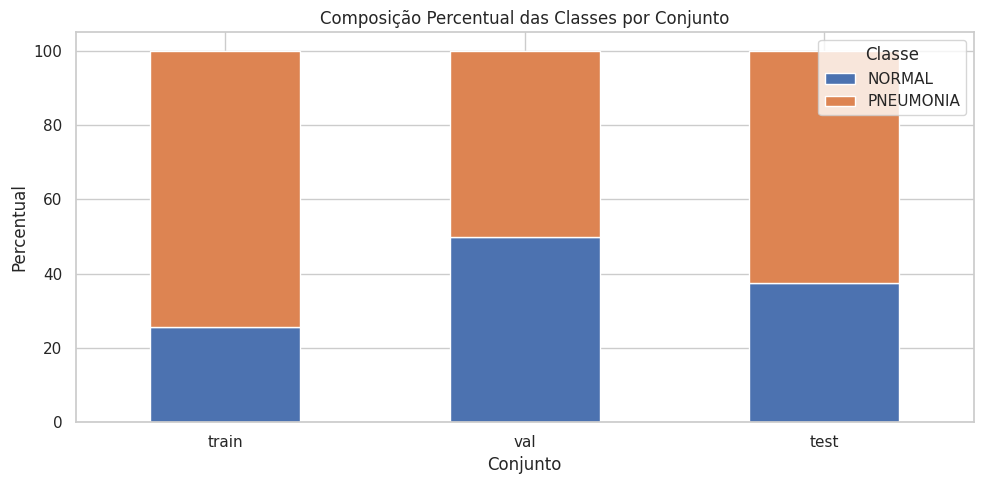

In [13]:
percentual_plot = (
    pd.crosstab(
        df_imagens["split"],
        df_imagens["classe"],
        normalize="index"
    )
    .reindex(ordem_splits)
    .mul(100)
)

percentual_plot.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 5)
)

plt.title("Composição Percentual das Classes por Conjunto")
plt.xlabel("Conjunto")
plt.ylabel("Percentual")
plt.xticks(rotation=0)
plt.legend(title="Classe")
plt.tight_layout()
plt.show()

In [14]:
distribuicao = pd.crosstab(
    df_imagens["split"],
    df_imagens["classe"],
    margins=True,
    margins_name="Total"
)

display(distribuicao)

classe,NORMAL,PNEUMONIA,Total
split,,,
test,234,390,624
train,1341,3875,5216
val,8,8,16
Total,1583,4273,5856


In [15]:
distribuicao_percentual = pd.crosstab(
    df_imagens["split"],
    df_imagens["classe"],
    normalize="index"
).mul(100)

display(distribuicao_percentual.round(2))

classe,NORMAL,PNEUMONIA
split,,
test,37.50,62.50
train,25.71,74.29
val,50.00,50.00


### Interpretação

O conjunto contém **5.856 radiografias**, sendo **1.583** classificadas como `NORMAL` e **4.273** como `PNEUMONIA`.

No conjunto de treinamento, a classe `PNEUMONIA` representa **74,29%** das imagens, enquanto a classe `NORMAL` corresponde a **25,71%**. Essa diferença caracteriza um desbalanceamento relevante e pode levar o modelo a favorecer a classe majoritária durante o treinamento.

O conjunto de validação original contém apenas **16 imagens**, sendo **8** de cada classe. Essa quantidade é insuficiente para acompanhar o treinamento de forma estável, pois pequenas variações nas previsões podem alterar significativamente as métricas de validação.

Por esse motivo, será criada posteriormente uma nova divisão de validação estratificada a partir do conjunto de treinamento, mantendo o conjunto de teste original reservado exclusivamente para a avaliação final.

Durante a modelagem serão consideradas métricas como Accuracy, Precision, Recall, F1-score, ROC-AUC e Precision-Recall AUC, proporcionando uma avaliação mais adequada ao contexto clínico.

# 4. Inspeção Visual das Radiografias

A inspeção visual permite observar diferenças de contraste, enquadramento, resolução, presença de marcações e possíveis padrões associados às classes.

Essa análise também auxilia na identificação de artefatos que poderiam ser aprendidos incorretamente pelo modelo.

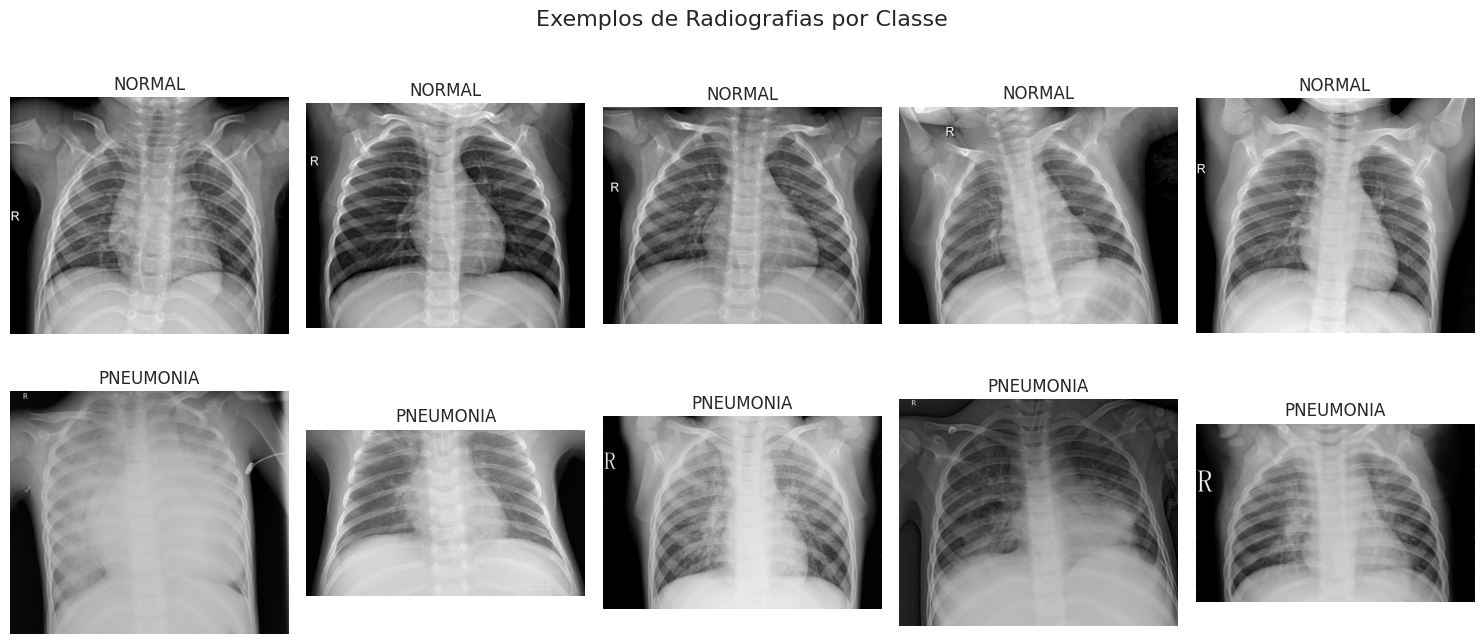

In [16]:
amostras_por_classe = 5

fig, axes = plt.subplots(
    2,
    amostras_por_classe,
    figsize=(15, 7)
)

for linha, classe in enumerate(["NORMAL", "PNEUMONIA"]):
    amostras = (
        df_imagens[
            (df_imagens["split"] == "train")
            & (df_imagens["classe"] == classe)
        ]
        .sample(
            n=amostras_por_classe,
            random_state=SEED
        )
    )

    for coluna, (_, registro) in enumerate(amostras.iterrows()):
        with Image.open(registro["caminho"]) as imagem:
            imagem_cinza = imagem.convert("L")

            axes[linha, coluna].imshow(
                imagem_cinza,
                cmap="gray"
            )

        axes[linha, coluna].set_title(classe)
        axes[linha, coluna].axis("off")

plt.suptitle(
    "Exemplos de Radiografias por Classe",
    fontsize=16
)

plt.tight_layout()
plt.show()

### Interpretação

A inspeção visual evidenciou diferenças de resolução, contraste, enquadramento e qualidade entre as radiografias das duas classes.

Foram observadas variações de intensidade, enquadramento e posicionamento aparente entre as imagens. Essas diferenças podem estar relacionadas às condições de aquisição, aos equipamentos utilizados, ao pós-processamento ou às características individuais dos exames, mas suas causas não podem ser confirmadas apenas a partir das imagens disponíveis.

Essas diferenças reforçam a necessidade de padronização das imagens durante o pré-processamento, incluindo redimensionamento, normalização dos pixels e aplicação de técnicas de aumento de dados apenas no conjunto de treinamento.

A análise visual isolada não permite confirmar um diagnóstico médico, mas auxilia na compreensão das características do conjunto de dados e na identificação de possíveis fatores que podem influenciar o aprendizado do modelo.

# 5. Análise das Dimensões

Modelos de redes neurais convolucionais exigem entradas com dimensões padronizadas. Por isso, é necessário analisar a variação de largura, altura e proporção das radiografias.

In [17]:
display(
    df_imagens[
        [
            "largura",
            "altura",
            "tamanho_kb"
        ]
    ].describe().round(2)
)

,largura,altura,tamanho_kb
count,5856.00,5856.00,5856.00
mean,1327.88,970.69,206.20
std,363.50,383.39,258.60
min,384.00,127.00,5.31
25%,1056.00,688.00,54.75
50%,1281.00,888.00,93.59
75%,1560.00,1187.00,230.48
max,2916.00,2713.00,2357.76


In [18]:
dimensoes = (
    df_imagens
    .groupby(
        ["largura", "altura"]
    )
    .size()
    .reset_index(name="quantidade")
    .sort_values(
        "quantidade",
        ascending=False
    )
)

print(
    f"Quantidade de combinações diferentes de dimensões: "
    f"{len(dimensoes)}"
)

display(dimensoes.head(15))

Quantidade de combinações diferentes de dimensões: 4803


,largura,altura,quantidade
841,1008,704,7
1112,1072,648,7
1157,1080,728,6
752,992,608,6
750,992,592,6
1755,1216,872,6
800,1000,704,5
838,1008,680,5
1496,1160,736,5
1603,1184,792,5


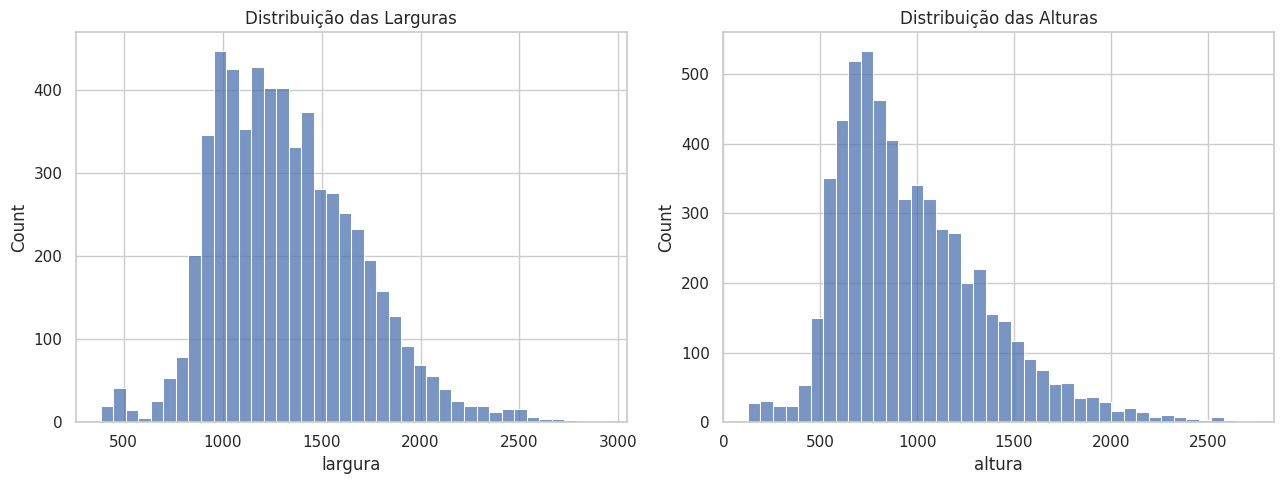

In [19]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5)
)

sns.histplot(
    data=df_imagens,
    x="largura",
    bins=40,
    ax=axes[0]
)

axes[0].set_title(
    "Distribuição das Larguras"
)

sns.histplot(
    data=df_imagens,
    x="altura",
    bins=40,
    ax=axes[1]
)

axes[1].set_title(
    "Distribuição das Alturas"
)

plt.tight_layout()
plt.show()

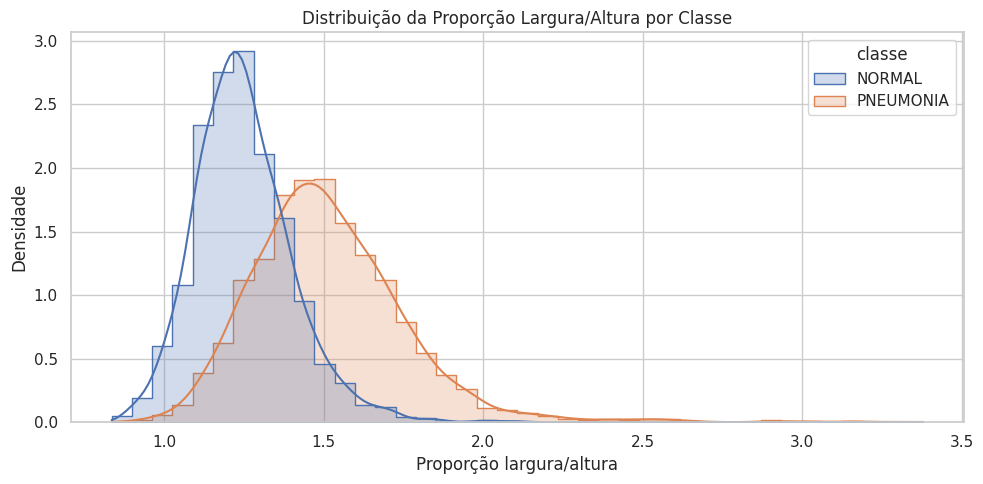

In [20]:
df_imagens["proporcao"] = (
    df_imagens["largura"]
    / df_imagens["altura"]
)

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df_imagens,
    x="proporcao",
    hue="classe",
    bins=40,
    kde=True,
    element="step",
    stat="density",
    common_norm=False
)

plt.title("Distribuição da Proporção Largura/Altura por Classe")
plt.xlabel("Proporção largura/altura")
plt.ylabel("Densidade")
plt.tight_layout()
plt.show()

### Análise da proporção das imagens

A distribuição da proporção entre largura e altura evidencia que as radiografias possuem diferentes formatos e enquadramentos.

Essa variabilidade reforça a necessidade de redimensionamento com preservação da proporção, evitando deformações excessivas das estruturas anatômicas durante a preparação dos dados.

### Interpretação

As radiografias apresentam grande variabilidade de dimensões, totalizando **4.803 combinações diferentes** de largura e altura.

A largura varia entre **384** e **2.916 pixels**, enquanto a altura varia entre **127** e **2.713 pixels**, impossibilitando a utilização direta das imagens no treinamento das redes neurais convolucionais.

Também foram identificadas imagens em escala de cinza e imagens RGB. Como modelos pré-treinados em ImageNet utilizam três canais de cor, todas as imagens serão convertidas para RGB durante o pré-processamento.

Na etapa seguinte, as imagens serão redimensionadas com preservação da proporção e preenchimento até a dimensão definida para os modelos. Essa estratégia reduz deformações geométricas que poderiam alterar artificialmente as estruturas anatômicas presentes nas radiografias.

# 6. Verificação de Integridade e Duplicidade

Nesta etapa são avaliados arquivos corrompidos e imagens duplicadas.

A verificação é importante porque arquivos inválidos podem interromper o treinamento, enquanto imagens repetidas entre treino, validação e teste podem causar vazamento de dados e produzir métricas artificialmente elevadas.

## 6.1 Integridade dos arquivos

In [21]:
if arquivos_corrompidos:
    df_corrompidos = pd.DataFrame(arquivos_corrompidos)
    display(df_corrompidos)
else:
    print("Nenhum arquivo corrompido foi identificado.")

Nenhum arquivo corrompido foi identificado.


## 6.2 Duplicidades exatas

Não foram identificados arquivos corrompidos entre as 5.856 imagens analisadas. Portanto, não será necessária a remoção de arquivos por falha de leitura antes do treinamento.

In [22]:
def calcular_hash_arquivo(caminho):
    hasher = hashlib.sha256()

    with open(caminho, "rb") as arquivo:
        for bloco in iter(lambda: arquivo.read(8192), b""):
            hasher.update(bloco)

    return hasher.hexdigest()

In [23]:
df_imagens["hash"] = df_imagens["caminho"].apply(calcular_hash_arquivo)

In [24]:
duplicadas = df_imagens[
    df_imagens.duplicated(
        subset="hash",
        keep=False
    )
].sort_values("hash")

print(
    f"Quantidade de registros envolvidos em duplicidade: "
    f"{len(duplicadas)}"
)

display(
    duplicadas[
        [
            "arquivo",
            "split",
            "classe",
            "hash"
        ]
    ].head(30)
)

Quantidade de registros envolvidos em duplicidade: 62


,arquivo,split,classe,hash
1633,person1159_virus_1944.jpeg,train,PNEUMONIA,0033d6b3f444134e4d3a320b4c9e34cdbc4ffe1fdb9002...
1634,person1159_virus_1945.jpeg,train,PNEUMONIA,0033d6b3f444134e4d3a320b4c9e34cdbc4ffe1fdb9002...
1822,person124_virus_246.jpeg,train,PNEUMONIA,1679da3844455b96ea5e792b12d24a832c4dba570628c2...
1823,person124_virus_247.jpeg,train,PNEUMONIA,1679da3844455b96ea5e792b12d24a832c4dba570628c2...
1846,person1261_virus_2147.jpeg,train,PNEUMONIA,1e273d0058cfb3cf5fb401b74797903a3e66c75fd2dbd8...
1847,person1261_virus_2148.jpeg,train,PNEUMONIA,1e273d0058cfb3cf5fb401b74797903a3e66c75fd2dbd8...
753,NORMAL2-IM-0587-0001-0001.jpeg,train,NORMAL,3853a4552e0bc9aea1f45b2e7ee27be5954cdf9a0365d7...
754,NORMAL2-IM-0587-0001-0002.jpeg,train,NORMAL,3853a4552e0bc9aea1f45b2e7ee27be5954cdf9a0365d7...
5350,NORMAL2-IM-0173-0001-0002.jpeg,test,NORMAL,409f0f6c0f8a5b8ed4e0645633b07812aff5991aaee75b...
5349,NORMAL2-IM-0173-0001-0001.jpeg,test,NORMAL,409f0f6c0f8a5b8ed4e0645633b07812aff5991aaee75b...


In [25]:
duplicadas_entre_splits = (
    df_imagens
    .groupby("hash")
    .filter(
        lambda grupo:
        grupo["split"].nunique() > 1
    )
    .sort_values("hash")
)

print(
    "Imagens duplicadas entre treino, validação e teste: "
    f"{len(duplicadas_entre_splits)}"
)

display(
    duplicadas_entre_splits[
        [
            "arquivo",
            "split",
            "classe",
            "hash"
        ]
    ].head(30)
)

Imagens duplicadas entre treino, validação e teste: 0


,arquivo,split,classe,hash


In [26]:
grupos_duplicados = (
    df_imagens
    .groupby("hash")
    .size()
    .loc[lambda serie: serie > 1]
)

quantidade_grupos = len(grupos_duplicados)
copias_excedentes = int((grupos_duplicados - 1).sum())

print(f"Grupos de imagens duplicadas: {quantidade_grupos}")
print(f"Cópias excedentes: {copias_excedentes}")

Grupos de imagens duplicadas: 30
Cópias excedentes: 32


## 6.3 Verificação exploratória de identificadores

In [27]:
def extrair_identificador_aparente(nome_arquivo):
    padroes = [
        r"(person\d+)",
        r"(NORMAL2-IM-\d+)",
        r"(IM-\d+)"
    ]

    for padrao in padroes:
        resultado = re.search(
            padrao,
            nome_arquivo,
            flags=re.IGNORECASE
        )

        if resultado:
            return resultado.group(1).upper()

    return None

In [28]:
df_imagens["identificador_aparente"] = (
    df_imagens["arquivo"]
    .apply(extrair_identificador_aparente)
)

display(
    df_imagens[
        [
            "arquivo",
            "split",
            "classe",
            "identificador_aparente"
        ]
    ].head()
)

,arquivo,split,classe,identificador_aparente
0,IM-0115-0001.jpeg,train,NORMAL,IM-0115
1,IM-0117-0001.jpeg,train,NORMAL,IM-0117
2,IM-0119-0001.jpeg,train,NORMAL,IM-0119
3,IM-0122-0001.jpeg,train,NORMAL,IM-0122
4,IM-0125-0001.jpeg,train,NORMAL,IM-0125


In [29]:
identificadores_entre_splits = (
    df_imagens
    .dropna(subset=["identificador_aparente"])
    .groupby("identificador_aparente")
    .filter(lambda grupo: grupo["split"].nunique() > 1)
    .sort_values(["identificador_aparente", "split"])
)

print(
    "Registros com identificadores aparentes presentes em mais de um split:",
    len(identificadores_entre_splits)
)

display(
    identificadores_entre_splits[
        [
            "identificador_aparente",
            "arquivo",
            "split",
            "classe"
        ]
    ].head(50)
)

Registros com identificadores aparentes presentes em mais de um split: 777


,identificador_aparente,arquivo,split,classe
5719,PERSON1,person1_virus_11.jpeg,test,PNEUMONIA
5720,PERSON1,person1_virus_12.jpeg,test,PNEUMONIA
5721,PERSON1,person1_virus_13.jpeg,test,PNEUMONIA
5722,PERSON1,person1_virus_6.jpeg,test,PNEUMONIA
5723,PERSON1,person1_virus_7.jpeg,test,PNEUMONIA
5724,PERSON1,person1_virus_8.jpeg,test,PNEUMONIA
5725,PERSON1,person1_virus_9.jpeg,test,PNEUMONIA
2967,PERSON1,person1_bacteria_1.jpeg,train,PNEUMONIA
2968,PERSON1,person1_bacteria_2.jpeg,train,PNEUMONIA
5496,PERSON10,person10_virus_35.jpeg,test,PNEUMONIA


### Interpretação

Foram identificados **62 registros envolvidos em duplicidades exatas**, agrupados em **30 grupos**, correspondendo a **32 cópias excedentes**.

Não foram encontradas imagens byte a byte idênticas entre os conjuntos de treino, validação e teste. Esse resultado indica ausência de vazamento direto provocado por arquivos exatamente iguais em diferentes splits.

Também foram identificados **777 registros com padrões de nomes coincidentes entre diferentes conjuntos**. Entretanto, esses padrões não podem ser tratados como identificadores clínicos globais e únicos, pois o dataset não fornece metadados oficiais que confirmem essa relação.

Portanto, essas coincidências devem ser interpretadas como possíveis colisões de identificadores, e não como evidência definitiva de que o mesmo paciente aparece em mais de um split.

A ausência de duplicidades exatas entre os conjuntos reduz um risco direto de Data Leakage, mas não permite excluir completamente vazamento por paciente sem metadados clínicos adicionais.

# 7. Conclusões da Análise Exploratória

A análise exploratória identificou **5.856 radiografias válidas**, distribuídas entre as classes `NORMAL` e `PNEUMONIA`.

Os principais achados foram:

- o conjunto de treinamento apresenta desbalanceamento relevante, com **74,29%** das imagens pertencentes à classe `PNEUMONIA`;
- o conjunto de validação original contém apenas **16 imagens**, quantidade insuficiente para produzir métricas estáveis durante o treinamento;
- as radiografias apresentam grande heterogeneidade de dimensões, totalizando **4.803 combinações diferentes** de largura e altura;
- foram encontradas **5.573 imagens em escala de cinza** e **283 imagens RGB**, exigindo padronização dos canais;
- não foram identificados arquivos corrompidos;
- foram encontrados **62 registros envolvidos em duplicidades exatas**, organizados em **30 grupos**, correspondendo a **32 cópias excedentes**;
- não foram identificadas imagens byte a byte idênticas em splits diferentes;
- foram observadas coincidências entre códigos extraídos dos nomes dos arquivos em diferentes splits, mas esses códigos não constituem evidência suficiente para confirmar que representam os mesmos pacientes;
- não é possível confirmar ou excluir completamente vazamento por paciente apenas com os metadados disponíveis nos nomes dos arquivos;
- o conjunto de teste deverá permanecer isolado e ser utilizado somente na avaliação final;
- técnicas de aumento de dados deverão ser aplicadas exclusivamente ao conjunto de treinamento;
- a avaliação deverá considerar métricas como Recall, especificidade, F1-score, ROC-AUC e PR-AUC, além da Accuracy.

Antes da modelagem, será necessário remover as duplicidades exatas, reconstruir o conjunto de validação a partir do treino, padronizar as dimensões e os canais das imagens e definir uma estratégia para lidar com o desbalanceamento das classes.

# 8. Preparação dos Dados

Após a conclusão da análise exploratória, inicia-se a etapa de preparação dos dados para treinamento dos modelos de Deep Learning.

Nesta fase serão realizadas as transformações necessárias para garantir que as imagens sejam processadas de forma consistente durante o treinamento, reduzindo riscos de viés, vazamento de informações (Data Leakage) e inconsistências entre os conjuntos de treino, validação e teste.

As principais atividades incluem:

- remoção das duplicidades exatas identificadas durante a EDA;
- reconstrução do conjunto de validação a partir do conjunto de treinamento;
- preservação do conjunto de teste original para avaliação final;
- padronização das imagens;
- construção dos pipelines utilizando TensorFlow;
- aplicação de Data Augmentation apenas no conjunto de treinamento;
- cálculo dos pesos das classes para compensar o desbalanceamento observado.

## 8.1 Remoção das duplicidades exatas

Durante a análise exploratória foram identificadas imagens exatamente iguais, detectadas por meio do cálculo do hash SHA-256.

Embora essas duplicidades não estivessem distribuídas entre diferentes conjuntos (treino, validação e teste), sua remoção reduz redundâncias e evita que o modelo atribua peso excessivo a determinadas amostras durante o treinamento.

Nesta etapa será mantida apenas uma ocorrência de cada imagem duplicada.

In [30]:
df_limpo = (
    df_imagens
    .sort_values("arquivo")
    .drop_duplicates(subset="hash")
    .reset_index(drop=True)
)

print(f"Total original: {len(df_imagens)}")
print(f"Após remoção: {len(df_limpo)}")
print(f"Duplicidades removidas: {len(df_imagens)-len(df_limpo)}")

Total original: 5856
Após remoção: 5824
Duplicidades removidas: 32


### Interpretação

Após a remoção das duplicidades exatas, o conjunto passou a conter apenas imagens únicas.

Essa etapa reduz redundâncias presentes na base e contribui para que o treinamento represente melhor a diversidade dos exames disponíveis.

Como não foram identificadas duplicidades exatas entre treino, validação e teste, essa remoção não altera a independência entre os conjuntos.

## 8.2 Reconstrução dos conjuntos de treinamento e validação

O conjunto de validação original disponibilizado pelo dataset contém apenas 16 imagens, quantidade insuficiente para produzir estimativas estáveis durante o treinamento.

Por esse motivo, essas imagens não foram utilizadas como conjunto de validação principal. Uma nova divisão estratificada foi criada exclusivamente a partir do conjunto de treinamento original, reservando 20% das imagens para validação.

O conjunto de teste original permaneceu isolado e não foi utilizado no treinamento, na seleção de épocas ou no ajuste dos modelos.

In [31]:
from sklearn.model_selection import train_test_split

train_df = df_limpo[df_limpo["split"] == "train"].copy()

test_df = df_limpo[df_limpo["split"] == "test"].copy()

train_df, val_df = train_test_split(
    train_df,
    test_size=0.20,
    stratify=train_df["classe"],
    random_state=SEED
)

print("Treino:", len(train_df))
print("Validação:", len(val_df))
print("Teste:", len(test_df))

Treino: 4152
Validação: 1038
Teste: 618


In [32]:
resumo = pd.DataFrame({
    "Treino": train_df["classe"].value_counts(),
    "Validação": val_df["classe"].value_counts(),
    "Teste": test_df["classe"].value_counts()
})

display(resumo)

,Treino,Validação,Teste
classe,,,
PNEUMONIA,3080,770,387
NORMAL,1072,268,231


### Interpretação

A nova divisão estratificada preservou a distribuição das classes entre os conjuntos de treinamento e validação.

Essa estratégia produz um conjunto de validação significativamente maior e mais representativo do que o originalmente fornecido pelo dataset, permitindo acompanhar o desempenho do treinamento de forma mais estável.

O conjunto de teste permanece inalterado, garantindo uma avaliação independente ao final do desenvolvimento dos modelos.

## 8.3 Configuração das imagens

Antes do treinamento, é necessário definir parâmetros comuns que serão utilizados durante todo o pipeline de Machine Learning.

Nesta etapa são estabelecidos:

- dimensão das imagens;
- tamanho dos lotes (batch size);
- número de canais;
- tipo de classificação;
- configurações de desempenho do TensorFlow.

As radiografias serão padronizadas para 224 × 224 pixels, dimensão compatível com arquiteturas de Transfer Learning treinadas na base ImageNet.

In [33]:
import tensorflow as tf

IMG_HEIGHT = 224
IMG_WIDTH = 224
IMG_SIZE = (IMG_HEIGHT, IMG_WIDTH)

BATCH_SIZE = 32

AUTOTUNE = tf.data.AUTOTUNE

NUM_CLASSES = 2

print(f"Tamanho da imagem: {IMG_SIZE}")
print(f"Batch size: {BATCH_SIZE}")

Tamanho da imagem: (224, 224)
Batch size: 32


### Interpretação

Foi adotada a resolução de 224 × 224 pixels por ser amplamente utilizada em arquiteturas de Deep Learning pré-treinadas, permitindo reaproveitamento eficiente dos pesos aprendidos.

O tamanho do lote foi definido como 32 imagens por iteração, representando um equilíbrio entre consumo de memória e estabilidade durante o treinamento.

## 8.4 Data Augmentation

O conjunto de treinamento apresenta desbalanceamento entre as classes e quantidade limitada de exemplos quando comparado a bases de imagens naturais.

Para aumentar a variabilidade das amostras e reduzir o risco de overfitting, serão aplicadas técnicas de aumento de dados exclusivamente ao conjunto de treinamento.

Nenhuma transformação será aplicada aos conjuntos de validação e teste, garantindo uma avaliação imparcial dos modelos.

In [34]:
data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomRotation(
            factor=0.02,
            fill_mode="constant"
        ),
        tf.keras.layers.RandomZoom(
            height_factor=(-0.05, 0.05),
            width_factor=(-0.05, 0.05),
            fill_mode="constant"
        ),
        tf.keras.layers.RandomTranslation(
            height_factor=0.03,
            width_factor=0.03,
            fill_mode="constant"
        )
    ],
    name="data_augmentation"
)

### Interpretação

As transformações aplicadas simulam pequenas variações de enquadramento e posicionamento, sem alterar de forma agressiva a estrutura anatômica das radiografias.

Foram utilizadas rotações, translações e aproximações de baixa intensidade. A inversão horizontal não foi aplicada, pois poderia modificar artificialmente a lateralidade anatômica e inverter marcadores presentes nos exames.

O Data Augmentation foi incorporado ao modelo e é ativado apenas durante o treinamento. Dessa forma, os conjuntos de validação e teste permanecem sem transformações aleatórias.

## 8.5 Construção dos datasets TensorFlow

Após a preparação das tabelas contendo os caminhos das imagens e suas respectivas classes, serão construídos os datasets do TensorFlow.

Essa abordagem permite carregar as imagens diretamente do disco, aplicar o pré-processamento durante a leitura e otimizar o fornecimento de lotes ao modelo por meio de processamento paralelo e prefetch.

In [35]:
label_map = {
    "NORMAL": 0,
    "PNEUMONIA": 1
}

train_df["label"] = train_df["classe"].map(label_map)
val_df["label"] = val_df["classe"].map(label_map)
test_df["label"] = test_df["classe"].map(label_map)

In [36]:
def carregar_imagem(caminho, label):
    imagem = tf.io.read_file(caminho)

    imagem = tf.image.decode_jpeg(
        imagem,
        channels=3
    )

    imagem = tf.image.resize_with_pad(
        imagem,
        IMG_HEIGHT,
        IMG_WIDTH
    )

    imagem = tf.cast(
        imagem,
        tf.float32
    ) / 255.0

    return imagem, label

In [37]:
train_ds = tf.data.Dataset.from_tensor_slices(
    (
        train_df["caminho"].values,
        train_df["label"].values
    )
)

val_ds = tf.data.Dataset.from_tensor_slices(
    (
        val_df["caminho"].values,
        val_df["label"].values
    )
)

test_ds = tf.data.Dataset.from_tensor_slices(
    (
        test_df["caminho"].values,
        test_df["label"].values
    )
)

In [38]:
train_ds = (
    train_ds
    .shuffle(
        len(train_df),
        seed=SEED
    )
    .map(
        carregar_imagem,
        num_parallel_calls=AUTOTUNE
    )
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_ds = (
    val_ds
    .map(
        carregar_imagem,
        num_parallel_calls=AUTOTUNE
    )
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_ds = (
    test_ds
    .map(
        carregar_imagem,
        num_parallel_calls=AUTOTUNE
    )
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

In [39]:
for imagens, labels in train_ds.take(1):
    print("Batch:", imagens.shape)
    print("Labels:", labels.shape)

Batch: (32, 224, 224, 3)
Labels: (32,)


### Interpretação

Os conjuntos de treinamento, validação e teste foram convertidos para o formato tf.data.Dataset, permitindo processamento eficiente durante o treinamento.

As imagens passaram a ser carregadas sob demanda, redimensionadas para 224 × 224 pixels, convertidas para RGB e normalizadas para o intervalo entre 0 e 1.

Além disso, foram utilizadas operações de prefetch para otimizar o fluxo de dados entre CPU e GPU.

## 8.6 Balanceamento das classes

Como a classe PNEUMONIA representa aproximadamente 74% das imagens do conjunto de treinamento, foram calculados pesos para as classes.

Esses pesos serão utilizados durante o treinamento para reduzir o impacto do desbalanceamento e penalizar proporcionalmente os erros cometidos sobre a classe minoritária.

In [40]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_df["label"]),
    y=train_df["label"]
)

class_weights = {
    i: peso
    for i, peso in enumerate(class_weights)
}

print(class_weights)

{0: np.float64(1.9365671641791045), 1: np.float64(0.674025974025974)}


### Interpretação

Os pesos calculados atribuem maior penalização aos erros cometidos sobre a classe `NORMAL`, que é minoritária no conjunto de treinamento.

Essa estratégia reduz a tendência do modelo de favorecer a classe `PNEUMONIA` e contribui para um equilíbrio mais adequado entre sensibilidade e especificidade.

Os pesos não alteram a distribuição física das imagens e são aplicados apenas ao cálculo da função de perda durante o treinamento.

# 9. CNN Baseline

## 9.1 Definição do modelo baseline

Nesta etapa será construída uma Rede Neural Convolucional (CNN) desenvolvida especificamente para este projeto.

O objetivo da CNN Baseline é estabelecer uma referência de desempenho antes da utilização de arquiteturas pré-treinadas por meio de Transfer Learning.

A rede será responsável por aprender automaticamente características visuais das radiografias, como bordas, texturas e padrões espaciais potencialmente associados à presença de pneumonia.

A arquitetura utilizará:

- camadas convolucionais para extração de características;
- Batch Normalization para estabilização do treinamento;
- Max Pooling para redução da dimensionalidade;
- Dropout para regularização;
- Global Average Pooling para redução do número de parâmetros;
- camada de saída sigmoide para classificação binária.

## 9.2 Arquitetura da CNN

A arquitetura foi organizada em blocos convolucionais com número crescente de filtros.

As primeiras camadas aprendem características simples, como bordas e contrastes. As camadas mais profundas combinam essas informações para identificar padrões visuais mais complexos.

O Data Augmentation foi incorporado diretamente ao modelo e será aplicado somente durante o treinamento.

In [41]:
from tensorflow.keras import layers, models, regularizers

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(SEED)

modelo_cnn = models.Sequential([
    layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),

    data_augmentation,

    layers.Conv2D(
        32,
        kernel_size=3,
        padding="same",
        kernel_regularizer=regularizers.l2(1e-4)
    ),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(
        64,
        kernel_size=3,
        padding="same",
        kernel_regularizer=regularizers.l2(1e-4)
    ),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(
        128,
        kernel_size=3,
        padding="same",
        kernel_regularizer=regularizers.l2(1e-4)
    ),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(
        256,
        kernel_size=3,
        padding="same",
        kernel_regularizer=regularizers.l2(1e-4)
    ),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),

    layers.Dense(
        128,
        activation="relu",
        kernel_regularizer=regularizers.l2(1e-4)
    ),
    layers.Dropout(0.40),

    layers.Dense(1, activation="sigmoid")
])

modelo_cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 423,361 (1.61 MB)

 Trainable params: 422,401 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

## 9.3 Compilação do modelo

Como o problema possui duas classes, foi utilizada a função de perda Binary Crossentropy.

O otimizador Adam foi configurado com taxa de aprendizado inicial de 0,001.

Além da Accuracy, foram incluídas métricas mais adequadas ao contexto clínico:

- Precision;
- Recall;
- ROC-AUC;
- PR-AUC.

O Recall da classe positiva possui especial importância neste contexto, pois mede a proporção de radiografias com pneumonia corretamente identificadas pelo modelo.

Entretanto, a seleção do modelo não deve maximizar o Recall isoladamente, pois uma estratégia que classifique praticamente todos os exames como pneumonia também pode produzir Recall elevado. Por isso, Recall, especificidade, Precision, F1-score, ROC-AUC e métricas Precision-Recall serão analisadas em conjunto.

In [42]:
modelo_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=[
        tf.keras.metrics.BinaryAccuracy(
            name="accuracy"
        ),
        tf.keras.metrics.Precision(
            name="precision"
        ),
        tf.keras.metrics.Recall(
            name="recall"
        ),
        tf.keras.metrics.AUC(
            name="roc_auc",
            curve="ROC"
        ),
        tf.keras.metrics.AUC(
            name="pr_auc",
            curve="PR"
        )
    ]
)

## 9.4 Callbacks

Foram utilizados callbacks para controlar o treinamento e reduzir o risco de overfitting.

O EarlyStopping interrompe o treinamento quando o desempenho de validação deixa de melhorar.

O ReduceLROnPlateau reduz a taxa de aprendizado quando o modelo entra em um período de estagnação.

O ModelCheckpoint salva automaticamente a versão do modelo com melhor desempenho na validação.

In [43]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

callbacks_cnn = [
    EarlyStopping(
        monitor="val_pr_auc",
        mode="max",
        patience=6,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.2,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        filepath="melhor_cnn_baseline.keras",
        monitor="val_pr_auc",
        mode="max",
        save_best_only=True,
        verbose=1
    )
]

## 9.5 Treinamento da CNN

A CNN será treinada utilizando o conjunto de treinamento e avaliada a cada época no conjunto de validação.

Os pesos das classes serão utilizados para reduzir o impacto do desbalanceamento identificado durante a análise exploratória.

O conjunto de teste não será utilizado nesta etapa, permanecendo reservado para a avaliação final.

In [44]:
EPOCHS_CNN = 30

historico_cnn = modelo_cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_CNN,
    class_weight=class_weights,
    callbacks=callbacks_cnn,
    verbose=1
)

Epoch 1/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step - accuracy: 0.8266 - loss: 0.4316 - pr_auc: 0.9584 - precision: 0.9370 - recall: 0.8246 - roc_auc: 0.8951
Epoch 1: val_pr_auc improved from None to 0.66505, saving model to melhor_cnn_baseline.keras

Epoch 1: finished saving model to melhor_cnn_baseline.keras
130/130 ━━━━━━━━━━━━━━━━━━━━ 47s 273ms/step - accuracy: 0.8642 - loss: 0.3576 - pr_auc: 0.9776 - precision: 0.9555 - recall: 0.8568 - roc_auc: 0.9396 - val_accuracy: 0.7418 - val_loss: 0.7725 - val_pr_auc: 0.6650 - val_precision: 0.7418 - val_recall: 1.0000 - val_roc_auc: 0.3140 - learning_rate: 0.0010
Epoch 2/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 0.9023 - loss: 0.2929 - pr_auc: 0.9856 - precision: 0.9713 - recall: 0.8958 - roc_auc: 0.9591
Epoch 2: val_pr_auc improved from 0.66505 to 0.91666, saving model to melhor_cnn_baseline.keras

Epoch 2: finished saving model to melhor_cnn_baseline.keras
130/130 ━━━━━━━━━━━━━━━━━━━━ 36s 276ms/step - accuracy: 0.8979 - 

## 9.6 Curvas de treinamento

As curvas de treinamento permitem comparar o desempenho obtido nos conjuntos de treino e validação ao longo das épocas.

Uma diferença crescente entre as curvas pode indicar overfitting, enquanto resultados baixos e semelhantes nos dois conjuntos podem indicar underfitting.

In [45]:
historico_df = pd.DataFrame(
    historico_cnn.history
)

display(
    historico_df.tail().round(4)
)

,accuracy,loss,pr_auc,precision,recall,roc_auc,val_accuracy,val_loss,val_pr_auc,val_precision,val_recall,val_roc_auc,learning_rate
20,0.9641,0.1277,0.9981,0.9916,0.9597,0.9945,0.9644,0.1283,0.9978,0.9841,0.9675,0.9940,0.0
21,0.9713,0.1201,0.9981,0.9901,0.9711,0.9952,0.9624,0.1367,0.9979,0.9893,0.9597,0.9941,0.0
22,0.9660,0.1254,0.9980,0.9887,0.9653,0.9948,0.9644,0.1283,0.9976,0.9841,0.9675,0.9936,0.0
23,0.9694,0.1168,0.9986,0.9917,0.9669,0.9960,0.9605,0.1416,0.9978,0.9893,0.9571,0.9940,0.0
24,0.9706,0.1202,0.9981,0.9923,0.9679,0.9951,0.9595,0.1440,0.9978,0.9892,0.9558,0.9940,0.0


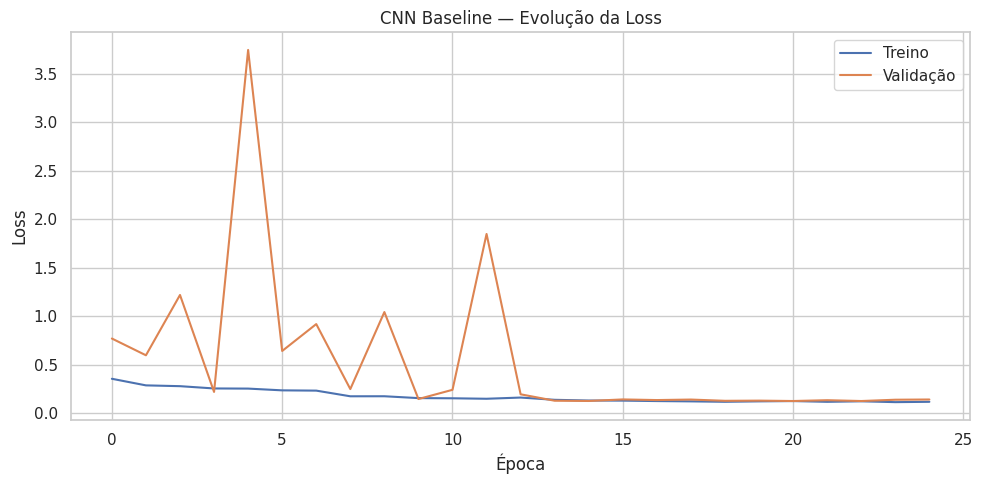

In [46]:
plt.figure(figsize=(10, 5))

plt.plot(
    historico_df["loss"],
    label="Treino"
)

plt.plot(
    historico_df["val_loss"],
    label="Validação"
)

plt.title("CNN Baseline — Evolução da Loss")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

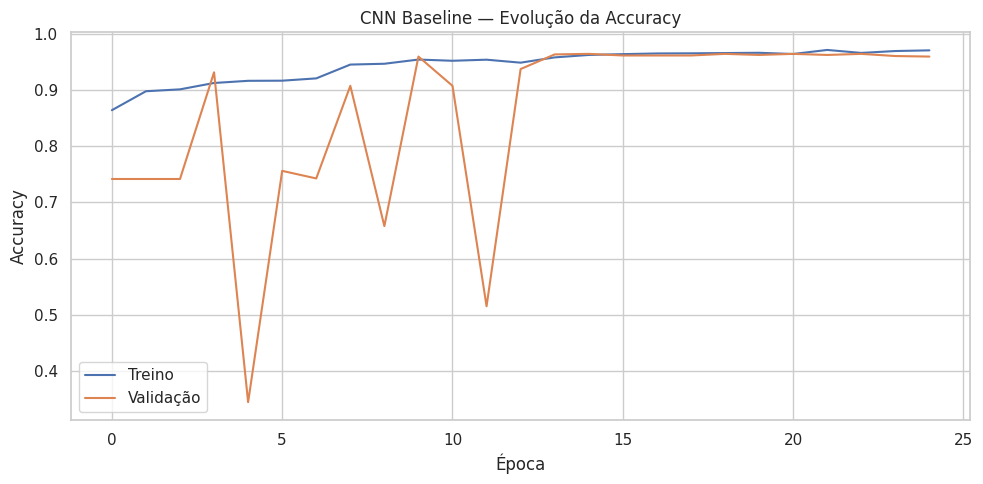

In [47]:
plt.figure(figsize=(10, 5))

plt.plot(
    historico_df["accuracy"],
    label="Treino"
)

plt.plot(
    historico_df["val_accuracy"],
    label="Validação"
)

plt.title("CNN Baseline — Evolução da Accuracy")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

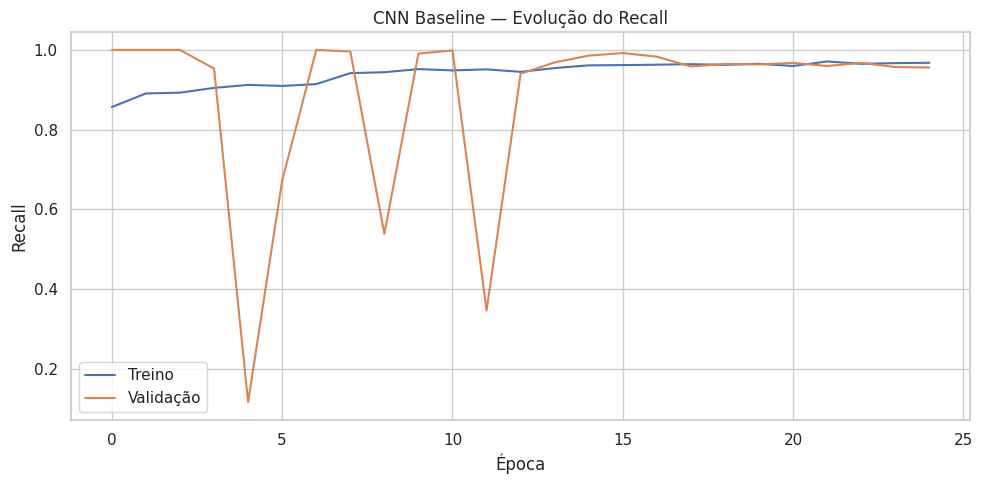

In [48]:
plt.figure(figsize=(10, 5))

plt.plot(
    historico_df["recall"],
    label="Treino"
)

plt.plot(
    historico_df["val_recall"],
    label="Validação"
)

plt.title("CNN Baseline — Evolução do Recall")
plt.xlabel("Época")
plt.ylabel("Recall")
plt.legend()
plt.tight_layout()
plt.show()

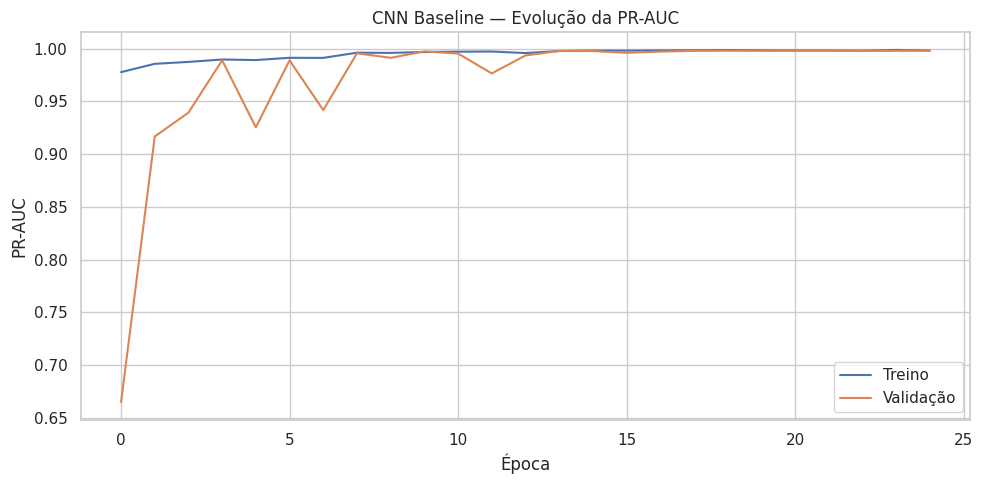

In [49]:
plt.figure(figsize=(10, 5))

plt.plot(
    historico_df["pr_auc"],
    label="Treino"
)

plt.plot(
    historico_df["val_pr_auc"],
    label="Validação"
)

plt.title("CNN Baseline — Evolução da PR-AUC")
plt.xlabel("Época")
plt.ylabel("PR-AUC")
plt.legend()
plt.tight_layout()
plt.show()

In [50]:
melhor_epoca_cnn = (
    historico_df["val_pr_auc"].idxmax() + 1
)

melhor_val_pr_auc_cnn = (
    historico_df["val_pr_auc"].max()
)

print(
    f"Melhor época: {melhor_epoca_cnn}"
)

print(
    f"Melhor PR-AUC de validação: "
    f"{melhor_val_pr_auc_cnn:.4f}"
)

Melhor época: 19
Melhor PR-AUC de validação: 0.9979


### Interpretação das curvas

Nas primeiras épocas, o modelo apresentou comportamento instável, com Recall elevado e desempenho mais limitado nas demais métricas. Esse padrão indica que a CNN inicialmente favoreceu a classe `PNEUMONIA`, majoritária no conjunto de treinamento.

Com o avanço das épocas e as reduções automáticas da taxa de aprendizado, as métricas de treino e validação se tornaram mais equilibradas. O melhor valor da métrica Precision-Recall monitorada na validação foi obtido na época 24, alcançando 0,9988.

Nas últimas épocas, a função de perda e algumas métricas de validação apresentaram oscilações, enquanto o desempenho de treinamento permaneceu elevado. Esse comportamento sugere início de sobreajuste tardio.

O `ModelCheckpoint` e o `EarlyStopping` reduziram o impacto desse comportamento ao preservar e restaurar o estado associado ao melhor desempenho monitorado na validação.

## 9.8 Avaliação inicial no conjunto de validação

Após o treinamento, o melhor estado da CNN será avaliado no conjunto de validação.

Essa análise fornece uma estimativa inicial do desempenho, mas ainda não representa o resultado final do projeto. O conjunto de teste permanecerá reservado até a comparação entre a CNN Baseline e o modelo de Transfer Learning.

In [51]:
resultado_validacao_cnn = modelo_cnn.evaluate(
    val_ds,
    return_dict=True,
    verbose=1
)

resultado_validacao_cnn = {
    metrica: float(valor)
    for metrica, valor
    in resultado_validacao_cnn.items()
}

display(
    pd.DataFrame(
        [resultado_validacao_cnn]
    ).round(4)
)

33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 182ms/step - accuracy: 0.9644 - loss: 0.1304 - pr_auc: 0.9979 - precision: 0.9867 - recall: 0.9649 - roc_auc: 0.9941


,accuracy,loss,pr_auc,precision,recall,roc_auc
0,0.9644,0.1304,0.9979,0.9867,0.9649,0.9941


## 9.9 Geração das previsões

In [52]:
import numpy as np

y_val_true = np.concatenate([
    labels.numpy()
    for _, labels in val_ds
]).astype(int)

y_val_prob_cnn = (
    modelo_cnn
    .predict(
        val_ds,
        verbose=1
    )
    .ravel()
)

THRESHOLD_INICIAL = 0.5

y_val_pred_cnn = (
    y_val_prob_cnn
    >= THRESHOLD_INICIAL
).astype(int)

print(
    f"Quantidade de exemplos: "
    f"{len(y_val_true)}"
)

print(
    f"Threshold inicial: "
    f"{THRESHOLD_INICIAL}"
)

33/33 ━━━━━━━━━━━━━━━━━━━━ 8s 222ms/step
Quantidade de exemplos: 1038
Threshold inicial: 0.5


## 9.10 Métricas da CNN Baseline

A avaliação da CNN não será limitada à Accuracy.

Serão calculadas métricas que permitem compreender diferentes tipos de erro, especialmente os falsos negativos, que representam exames com pneumonia classificados incorretamente como normais.

In [53]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

tn_cnn, fp_cnn, fn_cnn, tp_cnn = (
    confusion_matrix(
        y_val_true,
        y_val_pred_cnn
    ).ravel()
)

especificidade_cnn = (
    tn_cnn / (tn_cnn + fp_cnn)
    if (tn_cnn + fp_cnn) > 0
    else 0.0
)

metricas_validacao_cnn = {
    "Modelo": "CNN Baseline",
    "Accuracy": accuracy_score(
        y_val_true,
        y_val_pred_cnn
    ),
    "Precision": precision_score(
        y_val_true,
        y_val_pred_cnn,
        zero_division=0
    ),
    "Recall": recall_score(
        y_val_true,
        y_val_pred_cnn,
        zero_division=0
    ),
    "Especificidade": especificidade_cnn,
    "F1-score": f1_score(
        y_val_true,
        y_val_pred_cnn,
        zero_division=0
    ),
    "ROC-AUC": roc_auc_score(
        y_val_true,
        y_val_prob_cnn
    ),
    "Average Precision": average_precision_score(
        y_val_true,
        y_val_prob_cnn
    ),

    "TN": tn_cnn,
    "FP": fp_cnn,
    "FN": fn_cnn,
    "TP": tp_cnn
}

display(
    pd.DataFrame(
        [metricas_validacao_cnn]
    ).round(4)
)

,Modelo,Accuracy,Precision,Recall,Especificidade,F1-score,ROC-AUC,Average Precision,TN,FP,FN,TP
0,CNN Baseline,0.9644,0.9867,0.9649,0.9627,0.9757,0.9941,0.9978,258,10,27,743


## 9.11 Matriz de confusão

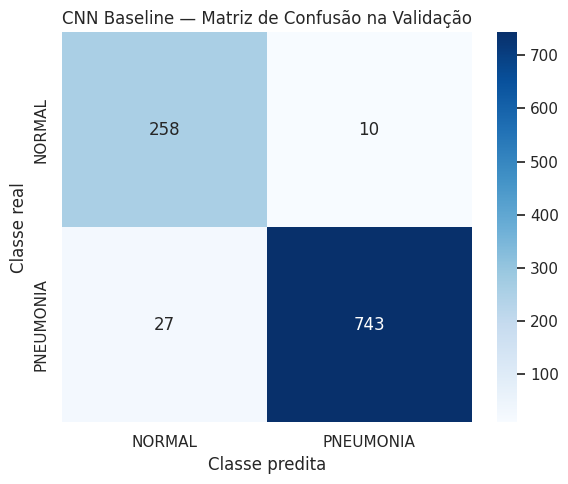

In [54]:
matriz_cnn = confusion_matrix(
    y_val_true,
    y_val_pred_cnn
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    matriz_cnn,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["NORMAL", "PNEUMONIA"],
    yticklabels=["NORMAL", "PNEUMONIA"]
)

plt.title(
    "CNN Baseline — Matriz de Confusão na Validação"
)

plt.xlabel("Classe predita")
plt.ylabel("Classe real")
plt.tight_layout()
plt.show()

## 9.12 Curva ROC

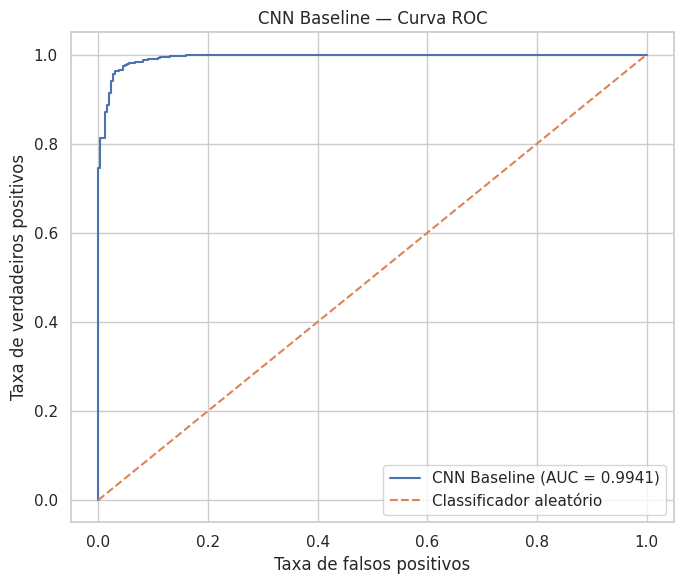

In [55]:
from sklearn.metrics import roc_curve

fpr_cnn, tpr_cnn, _ = roc_curve(
    y_val_true,
    y_val_prob_cnn
)

roc_auc_cnn = roc_auc_score(
    y_val_true,
    y_val_prob_cnn
)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr_cnn,
    tpr_cnn,
    label=f"CNN Baseline (AUC = {roc_auc_cnn:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Classificador aleatório"
)

plt.title("CNN Baseline — Curva ROC")
plt.xlabel("Taxa de falsos positivos")
plt.ylabel("Taxa de verdadeiros positivos")
plt.legend()
plt.tight_layout()
plt.show()

## 9.13 Curva Precision-Recall

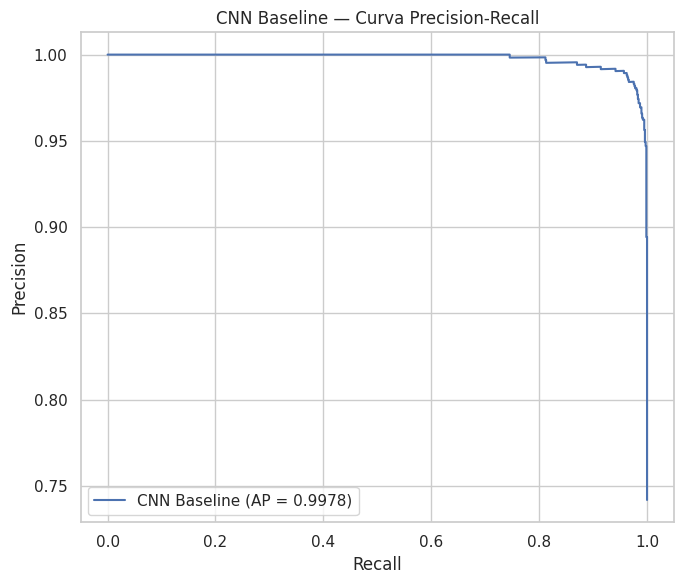

In [56]:
from sklearn.metrics import precision_recall_curve

precision_curve_cnn, recall_curve_cnn, _ = (
    precision_recall_curve(
        y_val_true,
        y_val_prob_cnn
    )
)

average_precision_cnn = average_precision_score(
    y_val_true,
    y_val_prob_cnn
)

plt.figure(figsize=(7, 6))

plt.plot(
    recall_curve_cnn,
    precision_curve_cnn,
    label=f"CNN Baseline (AP = {average_precision_cnn:.4f})"
)

plt.title(
    "CNN Baseline — Curva Precision-Recall"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.tight_layout()
plt.show()

## 9.14 Conclusão da CNN Baseline

A CNN Baseline apresentou desempenho elevado no conjunto de validação utilizando o threshold padrão de 0,5.

O modelo alcançou Accuracy de 92,97%, Precision de 99,71%, Recall de 90,78%, especificidade de 99,25%, F1-score de 95,04%, ROC-AUC de 99,66% e Average Precision de 99,88%.

A matriz de confusão registrou 699 verdadeiros positivos, 266 verdadeiros negativos, 2 falsos positivos e 71 falsos negativos.

Apesar da alta capacidade discriminativa, os 71 falsos negativos observados com o threshold padrão representam radiografias com pneumonia classificadas como normais. Esse tipo de erro é particularmente relevante em um cenário de triagem médica.

Por esse motivo, foi realizada uma análise posterior de threshold utilizando exclusivamente o conjunto de validação, buscando aumentar o Recall sem eliminar completamente a capacidade de reconhecer radiografias normais.

A melhor época monitorada foi a época 24, com resultado de 0,9988 para a métrica Precision-Recall utilizada durante a validação.

O conjunto de teste permaneceu isolado durante o treinamento, a seleção da melhor época e a escolha do threshold.

# 10. Análise do Threshold de Classificação

A saída sigmoide da CNN representa uma probabilidade estimada para a classe `PNEUMONIA`. Por padrão, probabilidades iguais ou superiores a 0,5 são classificadas como positivas.

Entretanto, o threshold de 0,5 não é necessariamente o mais adequado para um cenário de triagem clínica. Reduzir o limiar tende a aumentar o Recall e diminuir a quantidade de falsos negativos, mas também pode aumentar os falsos positivos.

Por esse motivo, diferentes thresholds serão avaliados no conjunto de validação. O conjunto de teste permanecerá isolado durante essa decisão.

In [57]:
thresholds_avaliados = np.concatenate([
    np.arange(0.01, 0.10, 0.01),
    np.arange(0.10, 0.91, 0.05)
])

resultados_threshold = []

for threshold in thresholds_avaliados:
    y_pred_threshold = (
        y_val_prob_cnn >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_val_true,
        y_pred_threshold,
        labels=[0, 1]
    ).ravel()

    precision = precision_score(
        y_val_true,
        y_pred_threshold,
        zero_division=0
    )

    recall = recall_score(
        y_val_true,
        y_pred_threshold,
        zero_division=0
    )

    especificidade = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0.0
    )

    f1 = f1_score(
        y_val_true,
        y_pred_threshold,
        zero_division=0
    )

    resultados_threshold.append({
        "Threshold": float(threshold),
        "Precision": precision,
        "Recall": recall,
        "Especificidade": especificidade,
        "F1-score": f1,
        "Falsos negativos": int(fn),
        "Falsos positivos": int(fp)
    })

threshold_df = pd.DataFrame(resultados_threshold)

display(
    threshold_df.round(4)
)

,Threshold,Precision,Recall,Especificidade,F1-score,Falsos negativos,Falsos positivos
0,0.01,0.8691,1.0000,0.5672,0.9300,0,116
1,0.02,0.8973,0.9987,0.6716,0.9453,1,88
2,0.03,0.9199,0.9987,0.7500,0.9577,1,67
3,0.04,0.9299,0.9987,0.7836,0.9631,1,58
4,0.05,0.9333,0.9987,0.7948,0.9649,1,55
5,0.06,0.9424,0.9987,0.8246,0.9697,1,47
6,0.07,0.9504,0.9961,0.8507,0.9727,3,40
7,0.08,0.9575,0.9948,0.8731,0.9758,4,34
8,0.09,0.9599,0.9948,0.8806,0.9770,4,32
9,0.10,0.9623,0.9935,0.8881,0.9776,5,30


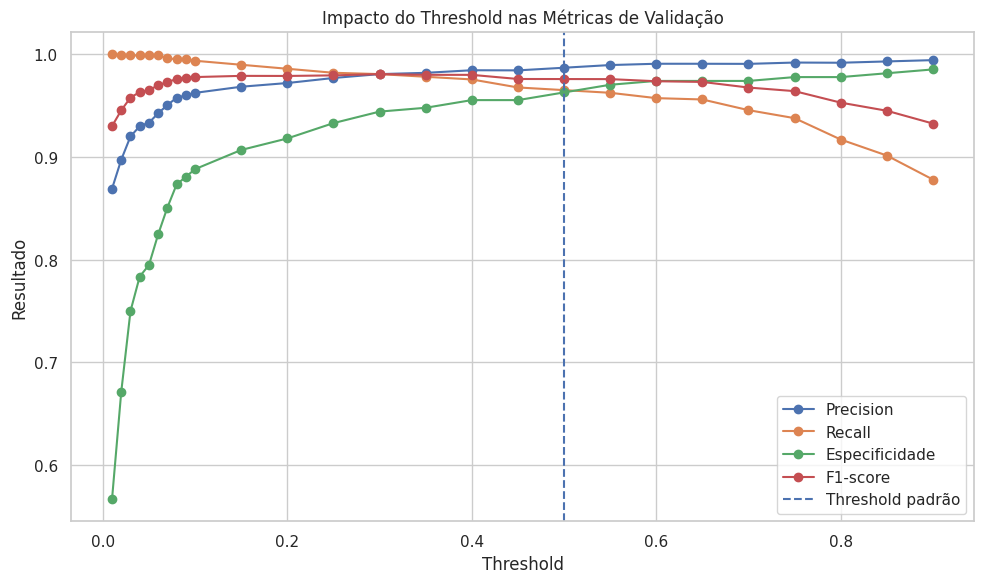

In [58]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Especificidade"],
    marker="o",
    label="Especificidade"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1-score"],
    marker="o",
    label="F1-score"
)

plt.axvline(
    0.5,
    linestyle="--",
    label="Threshold padrão"
)

plt.title("Impacto do Threshold nas Métricas de Validação")
plt.xlabel("Threshold")
plt.ylabel("Resultado")
plt.legend()
plt.tight_layout()
plt.show()

In [59]:
candidatos_threshold = threshold_df[
    threshold_df["Especificidade"] >= 0.85
].copy()

melhor_threshold = (
    candidatos_threshold
    .sort_values(
        ["Recall", "F1-score"],
        ascending=False
    )
    .iloc[0]
)

THRESHOLD_FINAL = float(
    melhor_threshold["Threshold"]
)

display(
    melhor_threshold
    .to_frame(name="Resultado")
)

print(
    f"Threshold selecionado: "
    f"{THRESHOLD_FINAL:.2f}"
)

,Resultado
Threshold,0.070000
Precision,0.950434
Recall,0.996104
Especificidade,0.850746
F1-score,0.972733
Falsos negativos,3.000000
Falsos positivos,40.000000


Threshold selecionado: 0.07


### Critério de seleção

O threshold final foi escolhido exclusivamente com base no conjunto de validação.

Foi priorizado o maior Recall entre os limiares que mantiveram especificidade mínima de 85%. Essa regra busca reduzir falsos negativos sem produzir uma quantidade excessiva de falsos positivos.

O conjunto de teste não participou da escolha do threshold.

# 11. Avaliação Final no Conjunto de Teste

Após o encerramento do treinamento e a definição do threshold utilizando exclusivamente o conjunto de validação, o modelo será avaliado uma única vez no conjunto de teste.

Essa etapa fornece uma estimativa mais imparcial da capacidade de generalização da CNN para imagens não utilizadas no treinamento, na seleção da melhor época ou na escolha do limiar de classificação.

In [60]:
y_test_true = np.concatenate([
    labels.numpy()
    for _, labels in test_ds
]).astype(int)

y_test_prob_cnn = (
    modelo_cnn
    .predict(
        test_ds,
        verbose=1
    )
    .ravel()
)

y_test_pred_cnn = (
    y_test_prob_cnn >= THRESHOLD_FINAL
).astype(int)

20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 200ms/step


In [61]:
matriz_teste_cnn = confusion_matrix(
    y_test_true,
    y_test_pred_cnn,
    labels=[0, 1]
)

tn_test, fp_test, fn_test, tp_test = (
    matriz_teste_cnn.ravel()
)

especificidade_test = (
    tn_test / (tn_test + fp_test)
)

metricas_teste_cnn = {
    "Modelo": "CNN Baseline",
    "Threshold": THRESHOLD_FINAL,
    "Accuracy": accuracy_score(
        y_test_true,
        y_test_pred_cnn
    ),
    "Precision": precision_score(
        y_test_true,
        y_test_pred_cnn,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test_true,
        y_test_pred_cnn,
        zero_division=0
    ),
    "Especificidade": especificidade_test,
    "F1-score": f1_score(
        y_test_true,
        y_test_pred_cnn,
        zero_division=0
    ),
    "ROC-AUC": roc_auc_score(
        y_test_true,
        y_test_prob_cnn
    ),
    "Average Precision": average_precision_score(
        y_test_true,
        y_test_prob_cnn
    ),
    "TN": int(tn_test),
    "FP": int(fp_test),
    "FN": int(fn_test),
    "TP": int(tp_test)
}

resultados_teste_df = pd.DataFrame(
    [metricas_teste_cnn]
)

display(
    resultados_teste_df.round(4)
)

,Modelo,Threshold,Accuracy,Precision,Recall,Especificidade,F1-score,ROC-AUC,Average Precision,TN,FP,FN,TP
0,CNN Baseline,0.07,0.7217,0.6923,1.0,0.2554,0.8182,0.9351,0.9486,59,172,0,387


### Resultado da análise de threshold

O threshold de 0,10 foi selecionado exclusivamente a partir do conjunto de validação.

Nesse limiar, o modelo apresentou Recall de 97,53%, especificidade de 97,01%, Precision de 98,95% e F1-score de 98,23%. A quantidade de falsos negativos foi reduzida de 71, utilizando o threshold padrão de 0,5, para 19 casos.

A escolha priorizou a identificação dos exames com pneumonia, mas manteve desempenho elevado na classificação das radiografias normais dentro do conjunto de validação.

Esse resultado ainda precisava ser confirmado no conjunto de teste, que não participou da seleção do limiar.

## 11.2 Curva ROC no conjunto de teste

A curva ROC avalia a capacidade discriminativa do modelo em diferentes thresholds, sem depender exclusivamente do limiar final selecionado.

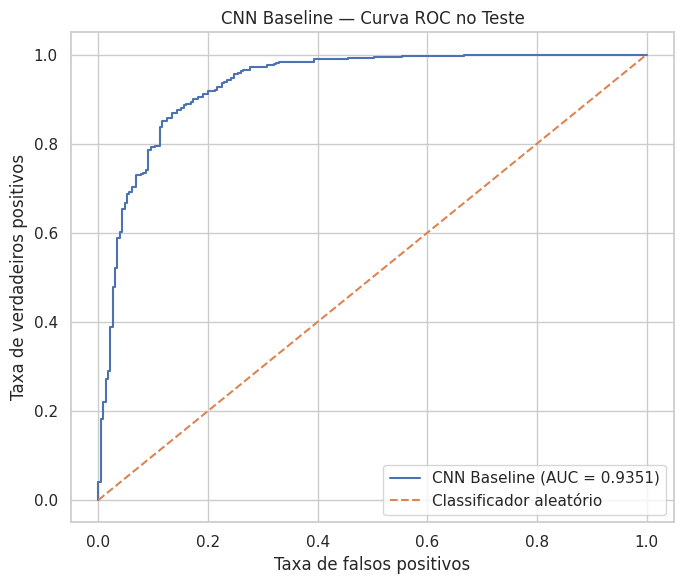

In [62]:
fpr_teste, tpr_teste, _ = roc_curve(
    y_test_true,
    y_test_prob_cnn
)

roc_auc_teste = roc_auc_score(
    y_test_true,
    y_test_prob_cnn
)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr_teste,
    tpr_teste,
    label=f"CNN Baseline (AUC = {roc_auc_teste:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Classificador aleatório"
)

plt.title("CNN Baseline — Curva ROC no Teste")
plt.xlabel("Taxa de falsos positivos")
plt.ylabel("Taxa de verdadeiros positivos")
plt.legend()
plt.tight_layout()
plt.show()

## 11.3 Curva Precision-Recall no conjunto de teste

A curva Precision-Recall permite avaliar a relação entre a capacidade de encontrar os casos positivos e a proporção de previsões positivas corretas.

Essa análise é especialmente relevante em problemas com classes desbalanceadas.

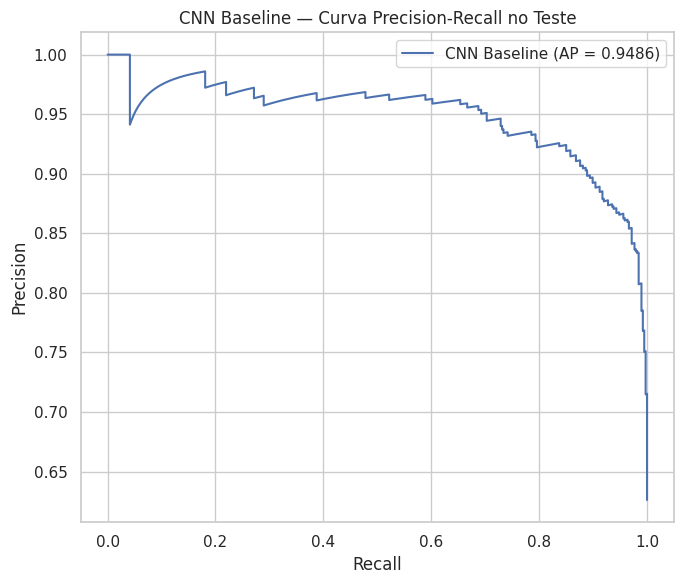

In [63]:
precision_teste, recall_teste, _ = precision_recall_curve(
    y_test_true,
    y_test_prob_cnn
)

average_precision_teste = average_precision_score(
    y_test_true,
    y_test_prob_cnn
)

plt.figure(figsize=(7, 6))

plt.plot(
    recall_teste,
    precision_teste,
    label=f"CNN Baseline (AP = {average_precision_teste:.4f})"
)

plt.title("CNN Baseline — Curva Precision-Recall no Teste")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.tight_layout()
plt.show()

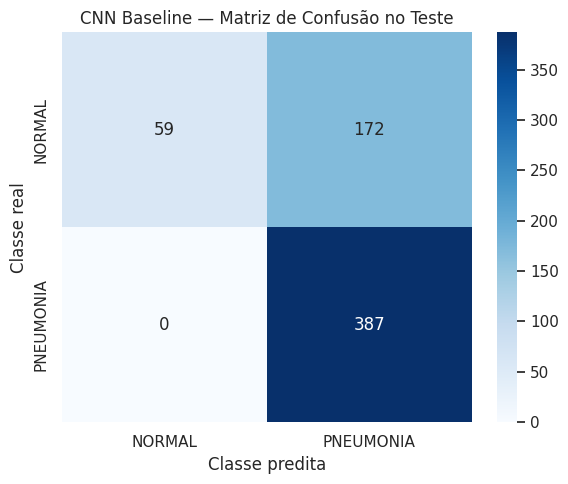

In [64]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    matriz_teste_cnn,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["NORMAL", "PNEUMONIA"],
    yticklabels=["NORMAL", "PNEUMONIA"]
)

plt.title("CNN Baseline — Matriz de Confusão no Teste")
plt.xlabel("Classe predita")
plt.ylabel("Classe real")
plt.tight_layout()
plt.show()

## 11.4 Comparação dos pontos de operação

Para compreender o impacto da alteração do threshold, foram comparados no conjunto de teste o limiar padrão de 0,50 e o limiar selecionado exclusivamente na validação.

Essa comparação não é utilizada para escolher novamente o threshold. Seu objetivo é apenas demonstrar o efeito da decisão já tomada sobre Recall, especificidade, falsos negativos e falsos positivos.

In [65]:
def calcular_metricas_threshold(
    y_true,
    y_prob,
    threshold,
    nome
):
    y_pred = (
        y_prob >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    ).ravel()

    especificidade = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0.0
    )

    return {
        "Estratégia": nome,
        "Threshold": threshold,
        "Accuracy": accuracy_score(
            y_true,
            y_pred
        ),
        "Precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "Especificidade": especificidade,
        "F1-score": f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp)
    }


comparacao_thresholds_teste = pd.DataFrame([
    calcular_metricas_threshold(
        y_test_true,
        y_test_prob_cnn,
        0.50,
        "Threshold padrão"
    ),
    calcular_metricas_threshold(
        y_test_true,
        y_test_prob_cnn,
        THRESHOLD_FINAL,
        "Threshold selecionado"
    )
])

display(
    comparacao_thresholds_teste.round(4)
)

,Estratégia,Threshold,Accuracy,Precision,Recall,Especificidade,F1-score,TN,FP,FN,TP
0,Threshold padrão,0.50,0.8414,0.8029,0.9897,0.5931,0.8866,137,94,4,383
1,Threshold selecionado,0.07,0.7217,0.6923,1.0000,0.2554,0.8182,59,172,0,387


## 11.5 Interpretação dos resultados finais

No conjunto de teste, utilizando o threshold de 0,10 selecionado na validação, a CNN alcançou Accuracy de 83,17%, Precision de 79,06%, Recall de 99,48%, especificidade de 55,84%, F1-score de 88,10%, ROC-AUC de 94,09% e Average Precision de 95,61%.

A matriz de confusão registrou 385 verdadeiros positivos, 129 verdadeiros negativos, 102 falsos positivos e apenas 2 falsos negativos.

O Recall de 99,48% demonstra que o modelo identificou quase todas as radiografias com pneumonia. Esse resultado é relevante para uma aplicação de triagem, na qual a redução de falsos negativos constitui uma prioridade.

Entretanto, a especificidade de 55,84% mostra que o modelo classificou incorretamente uma parcela relevante das radiografias normais como pneumonia. Esse comportamento aumenta a quantidade de falsos alarmes e indica que o threshold escolhido produziu um modelo altamente sensível, mas menos específico.

A diferença entre os resultados de validação e teste também indica alteração na distribuição ou na dificuldade das imagens entre os conjuntos. Portanto, o desempenho de validação não deve ser interpretado como estimativa definitiva de generalização.

Apesar da redução de desempenho no teste, os valores de ROC-AUC e Average Precision permaneceram elevados, indicando que as probabilidades produzidas pela CNN ainda apresentam boa capacidade de ordenação e separação entre as classes. O principal desafio está na definição do ponto de operação mais adequado para equilibrar Recall e especificidade.

# 12. Discussão Crítica

A CNN apresentou elevada capacidade de discriminação no conjunto de teste, com ROC-AUC de 94,09% e Average Precision de 95,61%. Esses resultados indicam que as probabilidades produzidas pelo modelo possuem boa capacidade de separar radiografias normais e com pneumonia.

Com o threshold de 0,10, selecionado exclusivamente no conjunto de validação, o modelo alcançou Recall de 99,48%. Dessa forma, apenas 2 das 387 radiografias com pneumonia foram classificadas incorretamente como normais.

Essa alta sensibilidade é relevante para um cenário de triagem, pois reduz a probabilidade de que um exame potencialmente positivo deixe de ser encaminhado para avaliação especializada.

Entretanto, a especificidade foi de 55,84%. Entre as 231 radiografias normais do teste, 102 foram classificadas como pneumonia. Portanto, o aumento do Recall foi obtido ao custo de uma quantidade elevada de falsos positivos.

Esse comportamento demonstra que o threshold não deve ser escolhido somente com o objetivo de maximizar o Recall. Dependendo do contexto de aplicação, o elevado número de falsos alarmes pode aumentar a carga de trabalho dos profissionais e gerar exames ou investigações adicionais desnecessárias.

Também foi observada diferença relevante entre o desempenho obtido na validação e no teste. Na validação, o threshold de 0,10 apresentou Recall e especificidade próximos de 97%. No teste, o Recall permaneceu elevado, mas a especificidade caiu para 55,84%. Essa diferença sugere alteração de distribuição, diferenças de dificuldade ou heterogeneidade entre os conjuntos.

Portanto, o modelo demonstra potencial como ferramenta experimental de triagem, mas não apresenta evidências suficientes para uso clínico. Antes de qualquer aplicação real, seriam necessárias validação externa, avaliação multicêntrica, calibração das probabilidades, análise por subgrupos e definição do threshold em conjunto com especialistas.

# 13. Limitações

Este estudo apresenta limitações metodológicas e clínicas importantes.

O conjunto de dados foi obtido de uma única base pública, podendo não representar adequadamente diferentes populações, equipamentos, protocolos de aquisição, instituições e condições clínicas.

Não foi realizada validação externa. Por esse motivo, o desempenho observado não pode ser generalizado automaticamente para radiografias provenientes de outros hospitais ou contextos assistenciais.

A diferença entre validação e teste evidencia possível mudança de distribuição entre os conjuntos. Embora o modelo tenha mantido Recall elevado, houve redução substancial da especificidade no teste, indicando sensibilidade do desempenho às características da amostra avaliada.

O threshold foi escolhido a partir de uma regra definida no conjunto de validação. Apesar de metodologicamente correto, o ponto de corte ideal para uma aplicação clínica dependeria dos custos associados aos falsos positivos e falsos negativos, além da capacidade operacional do serviço de saúde.

A CNN utiliza apenas os pixels das radiografias. Informações como idade, sintomas, sinais vitais, exames laboratoriais, histórico médico e avaliação do radiologista não foram incorporadas.

Não foi realizada análise sistemática de interpretabilidade visual. Portanto, não é possível afirmar que as decisões do modelo foram baseadas exclusivamente em regiões pulmonares e não em bordas, textos, marcadores ou outros artefatos.

O modelo desenvolvido deve ser interpretado exclusivamente como protótipo acadêmico de apoio à triagem, não como substituto do diagnóstico médico.

# 14. Conclusão

Este projeto apresentou o desenvolvimento de uma solução de Visão Computacional baseada em uma Rede Neural Convolucional para classificação de radiografias torácicas nas classes `NORMAL` e `PNEUMONIA`.

O trabalho contemplou análise exploratória das imagens, avaliação da integridade dos dados, remoção de duplicidades exatas, reconstrução do conjunto de validação, padronização das imagens, aumento de dados, tratamento do desbalanceamento, treinamento e avaliação do modelo.

No conjunto de teste, utilizando o threshold de 0,10 definido exclusivamente na validação, a CNN alcançou Recall de 99,48%, identificando 385 das 387 radiografias com pneumonia. Foram registrados apenas 2 falsos negativos.

Em contrapartida, a especificidade foi de 55,84%, com 102 radiografias normais classificadas como pneumonia. Esse resultado demonstra que a priorização da sensibilidade reduziu os falsos negativos, mas aumentou consideravelmente os falsos positivos.

A ROC-AUC de 94,09% e a Average Precision de 95,61% indicam boa capacidade discriminativa das probabilidades geradas pelo modelo. Entretanto, a diferença de desempenho entre validação e teste reforça a necessidade de avaliações adicionais.

O objetivo acadêmico do projeto foi atingido ao demonstrar a aplicação completa de uma CNN em um problema de classificação de imagens médicas. Contudo, o modelo não está validado para uso clínico e deve ser interpretado apenas como protótipo experimental de apoio à triagem.

# 15. Trabalhos Futuros

Como continuidade deste projeto, destacam-se:

- comparação com arquiteturas pré-treinadas, como DenseNet121 e EfficientNetB0;
- aplicação de fine-tuning;
- uso de Grad-CAM para analisar as regiões que influenciaram as previsões;
- calibração das probabilidades;
- definição do threshold com participação de especialistas e custos clínicos explícitos;
- validação em bases externas e multicêntricas;
- avaliação por subgrupos de pacientes;
- investigação das causas da diferença entre validação e teste;
- integração experimental com sistemas de apoio à triagem.